In [1]:
!git clone -b to_eval https://github.com/Jun-tsune/CS282_Final_Project.git

fatal: destination path 'CS282_Final_Project' already exists and is not an empty directory.


In [2]:
%cd CS282_Final_Project
!pip install munch tqdm omegaconf wandb pyyaml

/content/CS282_Final_Project


In [3]:
import sys, os
project_path = "/content/CS282_Final_Project"
sys.path.append(project_path)
sys.path.append(os.path.join(project_path, "src"))

In [4]:
!touch /content/CS282_Final_Project/src/__init__.py

In [5]:
#if don't use wandb online
#!export PYTHONPATH=$PYTHONPATH:/content/CS282_Final_Project:/content/CS282_Final_Project/src&& WANDB_MODE=offline python -m src.train model_yaml=config_model_1 train_yaml=config_train_1 out_dir=outputs_baseline test_run=False training.num_tasks=1

In [8]:
!export PYTHONPATH=$PYTHONPATH:/content/CS282_Final_Project:/content/CS282_Final_Project/src && python -m src.train model_yaml=config_model_1 train_yaml=config_train_experiment1 out_dir=outputs_baseline test_run=False

Running with: {'out_dir': 'outputs_baseline/id_cf8b5146-59f0-449f-9954-dd7704f80a95', 'model_yaml': 'src/config/config_model/config_model_1.yaml', 'train_yaml': 'src/config/config_train/config_train_experiment1.yaml', 'test_run': False, 'wandb': {'project': 'in-context-training', 'entity': 'UC_Berkeley_CS282', 'notes': None, 'log_every_steps': 100, 'name': None}, 'training': {'num_tasks': None, 'num_training_examples': None, 'task': 'linear_regression', 'data': 'gaussian', 'task_kwargs': {}, 'batch_size': 64, 'train_steps': 50000, 'curriculum': {'dims': {'start': 20, 'end': 20, 'inc': 1, 'interval': 200000}, 'points': {'start': 41, 'end': 41, 'inc': 1, 'interval': 200000}}, 'learning_rate': 0.0003, 'save_every_steps': 10000, 'keep_every_steps': 100000, 'resume_id': None, 'device': 'cuda'}, 'model': {'model_family': 'transformer', 'n_embd': 256, 'n_layer': 2, 'n_head': 8, 'n_dims': 10, 'n_positions': 128, 'embd_pdrop': 0.1, 'resid_pdrop': 0.0, 'attn_pdrop': 0.0}}
wandb: Currently logged

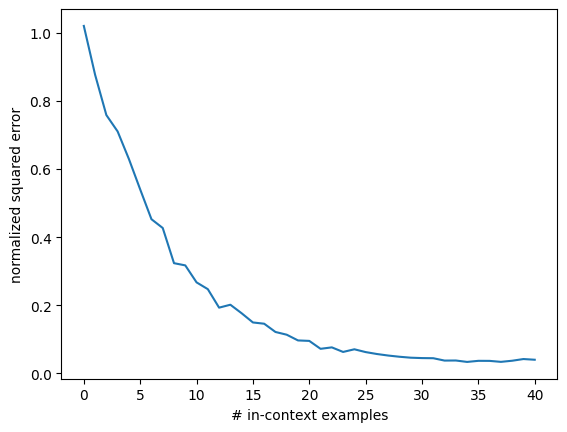

In [10]:
import json, numpy as np, matplotlib.pyplot as plt

with open("/content/CS282_Final_Project/outputs_baseline/id_2df617d5-5eeb-49ea-bfdd-785377cbe89a/metrics.json") as f:
    m = json.load(f)

curve = np.array(
    m["standard"]["transformer_embd=256_layer=2_head=8"]["mean"]
)
k = np.arange(len(curve))
d = 10

plt.plot(k, curve / d)
plt.xlabel("# in-context examples")
plt.ylabel("normalized squared error")
plt.show()
